Dataset Loaded Successfully
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Data Standardized Successfully

Original Shape : (150, 4)
Reduced Shape  : (150, 2)

Explained Variance Ratio:
[0.72962445 0.22850762]


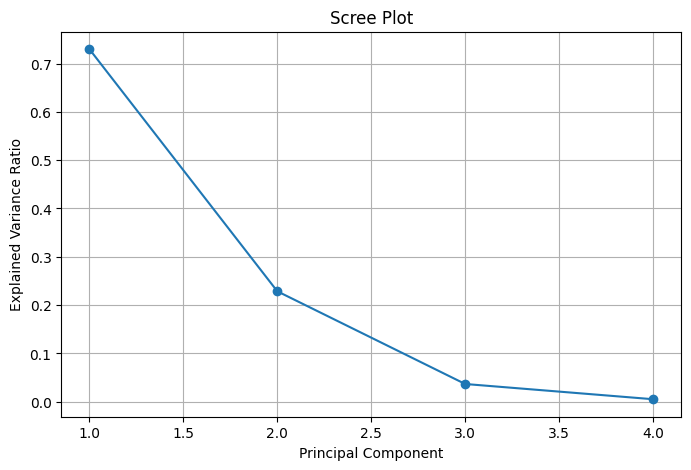

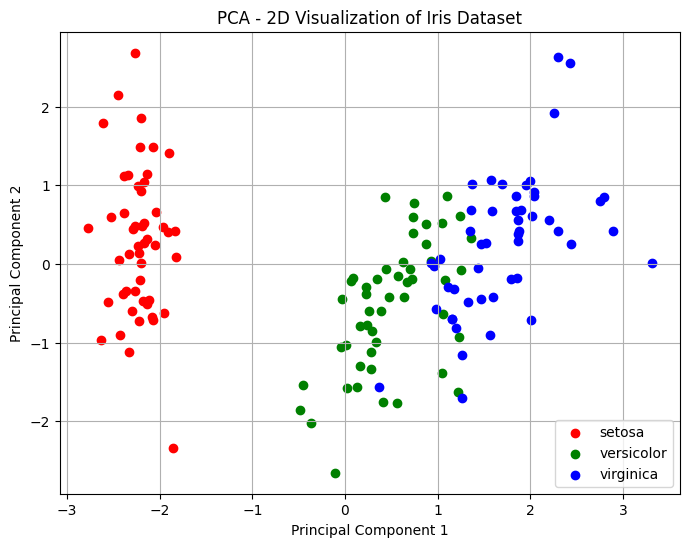


Principal Components:
[[ 0.52106591 -0.26934744  0.5804131   0.56485654]
 [ 0.37741762  0.92329566  0.02449161  0.06694199]]

Cumulative Explained Variance:
[0.72962445 0.95813207 0.99482129 1.        ]


In [1]:
# ==========================================
# Assignment 1
# PCA for Dimensionality Reduction
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ------------------------------------------
# 1. Load Dataset
# ------------------------------------------

# Using built-in Iris dataset
data = load_iris()

X = data.data
y = data.target

feature_names = data.feature_names

# Create DataFrame
df = pd.DataFrame(X, columns=feature_names)

print("Dataset Loaded Successfully")
print(df.head())

# ------------------------------------------
# 2. Standardization
# ------------------------------------------

# PCA works better when data is standardized

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("\nData Standardized Successfully")

# ------------------------------------------
# 3. Apply PCA
# ------------------------------------------

# Reduce dimensions from 4 → 2

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("\nOriginal Shape :", X.shape)
print("Reduced Shape  :", X_pca.shape)

# ------------------------------------------
# 4. Explained Variance
# ------------------------------------------

explained_variance = pca.explained_variance_ratio_

print("\nExplained Variance Ratio:")
print(explained_variance)

# ------------------------------------------
# 5. Scree Plot
# ------------------------------------------

# PCA with all components for scree plot

pca_full = PCA()

pca_full.fit(X_scaled)

variance_ratio = pca_full.explained_variance_ratio_

plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(variance_ratio)+1),
    variance_ratio,
    marker='o'
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")

plt.grid()
plt.show()

# ------------------------------------------
# 6. Lower Dimensional Visualization
# ------------------------------------------

plt.figure(figsize=(8,6))

colors = ['red', 'green', 'blue']

for i, color, label in zip(
    [0,1,2],
    colors,
    data.target_names
):
    plt.scatter(
        X_pca[y == i, 0],
        X_pca[y == i, 1],
        color=color,
        label=label
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title("PCA - 2D Visualization of Iris Dataset")

plt.legend()
plt.grid()

plt.show()

# ------------------------------------------
# 7. Principal Components
# ------------------------------------------

print("\nPrincipal Components:")
print(pca.components_)

# ------------------------------------------
# 8. Cumulative Explained Variance
# ------------------------------------------

cumulative_variance = np.cumsum(variance_ratio)

print("\nCumulative Explained Variance:")
print(cumulative_variance)

# ------------------------------------------
# END
# ------------------------------------------